# Signal-to-Noise Ratio (SNR) for an ASCON Leakage Model

This notebook estimates which **state-register bits** (at the end of the **first ASCON permutation**) are the best targets for a Side-Channel Analysis (SCA) attack.

A higher SNR typically indicates a **more distinguishable leakage**, and therefore a **better attack target**.

## Leakage model
The leakage model is the **Hamming Weight (HW)** of the selected target bit(s) at the end of the first ASCON permutation.

## S-box independence
**Note:** The SNR computation is *independent* of the specific S-box implementation used in ASCON.  
You can evaluate alternative S-boxes (beyond the standard ASCON one) as long as the corresponding traceset is available.

The notebook selects the input traceset file based on:
- the chosen `sbox_type`, and
- the number of traces `n_trc`.

⚠️ **Important:**  
This notebook assumes that power traces have already been acquired by running the **Power Trace Acquisition** notebook:
`xheep_capture_ASCON.ipynb`.

## Configuration parameters

| Parameter | Meaning |
|---|---|
| `snr_single_bit` | If `True`, compute SNR of bit `target_bit` and reg `target_register`|
| `target_register` | Target state word (e.g., `"x0"` or `"x1"`). |
| `target_bit` | Bit index to analyze (0–63). |
| `snr_all_bits` | If `True`, compute SNR for all 64 bits of the selected register(s). |
| `save_snr_all_bits` | If `True`, save the ranked SNR results to an `.h5` file. |
| `SNR_OUT_FILE` | Output `.h5` filename/path used when saving all-bits results. |
| `debug` | If `True`, enable debug prints. |

## First block: dataset selection

At the beginning of the notebook, select:
1) the S-box variant, and  
2) how many traces to use for the SNR computation.

In [ ]:
# Supported S-box types:
#   lut_ascon, lut_bilgin, lut_allouzi, lut_lu_4, lut_lu_5, lut_lu_6, lut_lu_7
sbox_type   = "lut_ascon"

# Number of traces in the traceset
n_trc = 10_000

In [2]:
import sys
import time
from pathlib import Path
import logging

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm
import h5py

## Project paths
This block robustly detects the project root (`DOJO_ROOT`) starting from either the script location (`__file__`) or the current working directory (for notebooks). From there it defines all relevant subdirectories (ASCON sources, SCA scripts, X-HEEP, traces, plots, cache), ensures output folders exist, and adds the local source paths to `sys.path` .

In [3]:
def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent

    raise RuntimeError(
        f"Could not find project root (looked for markers: {markers}). "
        "Please ensure you are inside the Side-Channel-Dojo repository."
    )

try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Notebook / interactive: start from CWD
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

ASCON_PY_DIR = DOJO_ROOT / "sw" / "ciphers" / "ASCON_init_python"
SCA_DIR      = DOJO_ROOT / "sw" / "sca_scripts"
HW_DIR       = DOJO_ROOT / "hw"

# Base dirs for ASCON SW SCA
BASE_PLOT_DIR  = DOJO_ROOT / "sw" / "sca_scripts" / "ASCON" / "sw" / "plot"
BASE_CACHE_DIR = DOJO_ROOT / "sw" / "sca_scripts" / "ASCON" / "sw" / "cache"

# Traceset (HDF5) directory and file
TRACESET_DIR  = DOJO_ROOT / "sw" / "traceset" / "ASCON" / "sw"
TRACESET_FILE = TRACESET_DIR / f"ascon_opt32_{sbox_type}_{n_trc // 1000}k.h5"

# Per-S-box plot and cache directory 
PLOT_DIR = BASE_PLOT_DIR / sbox_type
CACHE_DIR = BASE_CACHE_DIR / sbox_type

# Ensure directories exist
BASE_PLOT_DIR.mkdir(parents=True, exist_ok=True)
BASE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
TRACESET_DIR.mkdir(parents=True, exist_ok=True)

# Make local modules importable
sys.path.insert(0, str(ASCON_PY_DIR))
sys.path.insert(0, str(SCA_DIR))

from analyzer.attack.ascon.xheep_ascon_cpa.ascon_first_round import ascon_first_round

## SNR notebook configuration

In [4]:
# ---------------------------------------------------------------------------
# SNR notebook configuration
# ---------------------------------------------------------------------------
# Compute SNR of single bit and plot it 
snr_single_bit   = True    
target_bit       = 49
target_register  = "x0"    # "x0" or "x1"  (#TODO extend later to "x2","x3","x4" also)
# Compute SNR for all bits
snr_all_bits     = True   

# Output control
save_plots        = True   # Save plots to disk
save_snr_all_bits = True  # Save snr ranked to disk
SNR_OUT_FILE      = CACHE_DIR / "snr_ranked.h5"

# Flow flags
debug           = False

# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------

def _yn(flag: bool) -> str:
    return "yes" if flag else "no"

print("\n================= CONFIGURATION =================")
print(f"DOJO_ROOT                : {DOJO_ROOT}")
print()
print("Target")
print(f"  Cipher                 : ASCON")
print(f"  S-box implementation   : {sbox_type}")
print(f"  Notebook scope         : SNR analysis on ASCON SW traces")
print()
print("Paths")
print(f"  Traceset file          : {TRACESET_FILE}")
print(f"  Plot dir               : {PLOT_DIR}")
print()
print("SNR configuration")
print(f"  Total traces           : {n_trc}")
print(f"  SNR all bits           : {_yn(snr_all_bits)}")
if snr_all_bits:
    print(f"  SNR all-bits output    : {SNR_OUT_FILE}")
if snr_single_bit:
    print(f"  SNR single bit         : {target_register}[{target_bit}]")
print("=================================================\n")


================= CONFIGURATION =================
DOJO_ROOT                : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  Cipher                 : ASCON
  S-box implementation   : lut_ascon
  Notebook scope         : SNR analysis on ASCON SW traces

Paths
  Traceset file          : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/sw/ascon_opt32_lut_ascon_10k.h5
  Plot dir               : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/ASCON/sw/plot/lut_ascon

SNR configuration
  Total traces           : 10000
  SNR all bits           : yes
  SNR all-bits output    : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/ASCON/sw/cache/lut_ascon/snr_ranked.h5
  SNR single bit         : x0[49]



## Load traceset
- Opens the HDF5 traces file `TRACESET_FILE` in read mode.
- Checks that both datasets `"traces"` and `"nonces"` are present.
- Reads:
  - Up to `n_trc` traces and their corresponding nonces.
  - Metadata: `sampling_interval`, `n_samples`, `key`, `iv`.
- Verifies that the number of traces matches the number of nonces.
- Warns if the requested `n_trc` differs from the number of traces stored.


In [5]:
try:
    with h5py.File(TRACESET_FILE, "r") as f_read_traces:
        # Basic sanity: check that required datasets exist
        if "traces" not in f_read_traces or "nonces" not in f_read_traces:
            raise KeyError(
                "HDF5 file is missing required datasets 'traces' and/or 'nonces'."
            )

        traces_ds = f_read_traces["traces"]
        nonces_ds = f_read_traces["nonces"]

        total_traces = traces_ds.shape[0]
        n_samples    = traces_ds.shape[1]

        # Load metadata attributes (if present)
        sampling_interval   = f_read_traces.attrs.get("sampling_interval", None)
        n_samples           = f_read_traces.attrs.get("n_samples", n_samples)
        key_hex             = f_read_traces.attrs.get("key_hex", None) 
        iv_hex              = f_read_traces.attrs.get("iv_hex", None)

        # Use at most n_trc traces, but do not exceed what's in the file
        n_used = min(n_trc, total_traces)

        # Use slicing so data are actually loaded into RAM
        traces = traces_ds[:n_used]
        nonces = nonces_ds[:n_used]

    # Sanity check: traces and nonces should have the same number of rows
    if traces.shape[0] != nonces.shape[0]:
        raise ValueError(
            f"Number of traces ({traces.shape[0]}) and nonces ({nonces.shape[0]}) "
            "do not match. Check the traces file."
        )

    # Optional sanity checks vs metadata
    if n_trc != total_traces:
        print(
            f"[WARN] Wanted n_trc={n_trc} "
            f"differs from dataset length={total_traces}"
        )
    n_trc = n_used
        
    # Rebuild the first nonce in big-endian hex (undo byte reversal)    
    nonce_msb = int(nonces[0, 0])  # 0x0F0E0D0C0B0A0908
    nonce_lsb = int(nonces[0, 1])  # 0x0706050403020100
    nonce_stored_int = (nonce_msb << 64) | nonce_lsb
    nonce_original_bytes = nonce_stored_int.to_bytes(16, byteorder="big")[::-1]
    nonce_original_hex = nonce_original_bytes.hex().upper()

    print(f"[INFO] Loaded {traces.shape[0]} traces from {TRACESET_FILE}")
    print(f"[INFO] Sampling interval      : {sampling_interval}")
    print(f"[INFO] Samples per trace      : {n_samples}")
    if key_hex is not None:
        print(f"[INFO] Key                    : 0x{key_hex}")
    else:
        print("[WARN] Key hex attribute 'key_hex' not found in HDF5 file.")
    if iv_hex is not None:
        print(f"[INFO] IV                     : 0x{iv_hex}")
    else:
        print("[WARN] IV hex attribute 'iv_hex' not found in HDF5 file.")
        print(f"[INFO] Initial nonce          : 0x{nonce_original_hex}")

except FileNotFoundError:
    print(
        f"[ERROR] Traces file {TRACESET_FILE} not found. "
        "Please run the trace acquisition phase first."
    )
except Exception as e:
    print(f"[ERROR] Could not read traces file {TRACESET_FILE}: {e}")

[INFO] Loaded 10000 traces from /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/sw/ascon_opt32_lut_ascon_10k.h5
[INFO] Sampling interval      : 8e-09
[INFO] Samples per trace      : 1125
[INFO] Key                    : 0x000102030405060708090A0B0C0D0E0F
[INFO] IV                     : 0x00001000808C0001


## Computing the SNR 

### Utility functions

In [6]:
# Utility functions
def prepare_data(trace_set, labels_set):
    """
    trace_set = a set of traces
    labels_set = the leakage model of the target intermediate value
    
    returns a dictionary of the form
       'label_value': list of traces associated with 'label_value'
    """
   
    labels=np.unique(labels_set)
    # Initialize the dictionary
    d={}
    for i in labels:
         d[i]=[]
    for count, label in enumerate(labels_set):
        d[label].append(trace_set[count])
    return d

def return_snr_trace(trace_set, labels_set):
    """
    trace_set = a set of traces
    labels_set = a set of labels of the same lenght as trace_set

    returns a dictionary of the form
       'label_value': mean_sample trace with 'label_value'
    """
    mean_trace={}
    signal_trace=[]
    noise_trace=[]
    # Determine the set of unique values for the leakage model. In this case,
    # the leakage model is the attacked bit, so the labels = {0,1}.
    labels=np.unique(labels_set)
    # Group the traces according to the label
    grouped_traces=prepare_data(trace_set, labels_set)
    # Compute the mean trace (the same are the signal traces)
    for i in labels:
        mean_trace[i]=np.mean(grouped_traces[i], axis=0)
        signal_trace.append(mean_trace[i])
    # Compute the noise trace
    for i in labels:
        for trace in grouped_traces[i]:
            noise_trace.append(trace-mean_trace[i])
    var_noise=np.var(noise_trace, axis=0)
    var_signal=np.var(signal_trace, axis=0)
    snr_trace=var_signal/var_noise
    return snr_trace

## SNR of single bit

In [ ]:
# Reverse key by bytes (2 hex chars per byte) to match C endianness
key_bytes    = [key_hex[i:i+2] for i in range(0, len(key_hex), 2)]
key_reversed = "".join(key_bytes[::-1])
key_int      = int(key_reversed, 16)

In [8]:
if (snr_single_bit):
    # Divide the traces according to the target bit value of the 
    # output register S0 or S1 at the end of the linear diffusion layer.
    label_attacked_bit=[]
    for i in range(0, n_trc):
        # Reconstruct the 128-bit nonce from the two 64-bit halves
        nonce = int(nonces[i][0]) << 64 | int(nonces[i][1])
        # Compute the expected value of the state at the end of the first round
        S = ascon_first_round(key_int, nonce, sbox_type)
        # Split traces based on the value of the target bit in state register 
        if target_register == "x0":
            label_attacked_bit.append((S[0] >> target_bit) & 0x01)
        else:
            label_attacked_bit.append((S[1] >> target_bit) & 0x01)
    snr_trace_attacked_bit = return_snr_trace(traces, label_attacked_bit)

## Plot for the target bit the _SNR vs Samples_ 

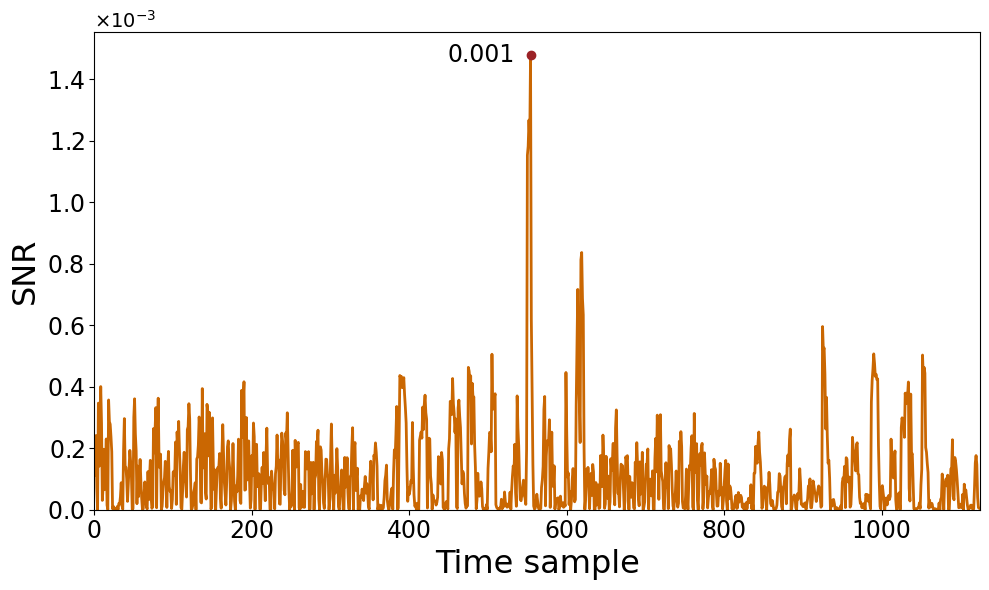

In [9]:
if (snr_single_bit):
    fig, ax = plt.subplots(figsize=(10, 6))
    snr = np.asarray(snr_trace_attacked_bit)
    x = np.arange(len(snr))

    ax.plot(x, snr, color='#ca6702', linewidth=2)

    # find max and annotate (no arrow, text moved left)
    imax = int(np.argmax(snr))
    vmax = float(snr[imax])
    ax.plot(imax, vmax, 'o', color='#9b2226', markersize=6)
    ax.annotate(f"{vmax:.3f}",
                xy=(imax, vmax),
                xytext=(imax - 20, vmax),
                textcoords='data',
                ha='right',
                va='center',
                color='black',
                fontsize=17)


    ax.tick_params(axis='y', labelcolor='black', labelsize=17)
    ax.tick_params(axis='x', labelsize=17)
    # force scientific notation when values are ~1e-3 or smaller (shows "×10⁻³" offset)
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-3, 0))   # switch to scientific for exponents <= -3
    ax.yaxis.set_major_formatter(fmt)
    ax.yaxis.get_offset_text().set_fontsize(14)  # adjust offset font size if needed

    # set x limit from 0 to len(x) and y to start from 0
    ax.set_xlim(0, len(x))            # Split traces based on the value of the target bit in state register 
    ax.set_ylim(bottom=0)
    #ax.set_title(f"SNR trace for bit {target_bit + target_register*64} of reg X0")
    ax.set_xlabel('Time sample', fontsize=23)
    ax.set_ylabel('SNR', fontsize=23)
    ax.grid(False)
    plt.tight_layout()
    out_file = PLOT_DIR/ f"ASCON_snr_bit_{target_register}[{target_bit}].pdf"
    if save_plots:
        plt.savefig(out_file, bbox_inches="tight")
    plt.show()
    plt.close()

### SNR for each bit if set `snr_all_bits`

In [10]:
if snr_all_bits:
    # -------------------------------------------------------------------------
    # Compute max-SNR for all 64 bits of both registers:
    #   - x0 = S[0]
    #   - x1 = S[1]
    #
    # Store results in three parallel arrays (same length):
    #   rank_regs[k] : "x0" or "x1"
    #   rank_bits[k] : bit index (0..63)
    #   rank_snr[k]  : max SNR value for that (reg, bit)
    #
    # Then sort all three arrays by descending SNR.
    # -------------------------------------------------------------------------

    rank_regs = []
    rank_bits = []
    rank_snr  = []

    for bit_i in tqdm(range(64), desc="Computing SNR over bits (0..63) for both x0 and x1"):
        # Labels for this bit (one per trace) for S0 and S1
        labels_S0 = np.empty(n_trc, dtype=np.uint8)
        labels_S1 = np.empty(n_trc, dtype=np.uint8)

        for i in range(n_trc):
            nonce = (int(nonces[i][0]) << 64) | int(nonces[i][1])
            S = ascon_first_round(key_int, nonce, sbox_type)

            labels_S0[i] = (S[0] >> bit_i) & 0x01
            labels_S1[i] = (S[1] >> bit_i) & 0x01

        # Compute SNR traces for S0 and S1 labels
        snr_trace_S0 = return_snr_trace(traces, labels_S0)  # (n_samples,)
        snr_trace_S1 = return_snr_trace(traces, labels_S1)  # (n_samples,)

        # Peak SNR used as ranking score
        max_snr_S0 = float(np.max(snr_trace_S0))
        max_snr_S1 = float(np.max(snr_trace_S1))

        # Append results
        rank_regs.append("x0"); rank_bits.append(bit_i); rank_snr.append(max_snr_S0)
        rank_regs.append("x1"); rank_bits.append(bit_i); rank_snr.append(max_snr_S1)

        if debug:
            print(f"[DBG] bit {bit_i:2d} -> x0 SNR_max={max_snr_S0:.6g}, x1 SNR_max={max_snr_S1:.6g}")

    # Convert lists to numpy arrays
    rank_regs = np.array(rank_regs, dtype=h5py.string_dtype(encoding="utf-8"))
    rank_bits = np.array(rank_bits, dtype=np.uint16)
    rank_snr  = np.array(rank_snr,  dtype=np.float64)

    # Sort all entries by descending SNR
    order = np.argsort(rank_snr)[::-1]
    rank_regs = rank_regs[order]
    rank_bits = rank_bits[order]
    rank_snr  = rank_snr[order]


    if debug:
        print("\n[DBG] Top 10 ranked (reg, bit, maxSNR):")
        for k in range(min(10, len(rank_snr))):
            print(f"  [{rank_regs[k]}, {int(rank_bits[k])}, {rank_snr[k]:.6g}]")

    # -------------------------------------------------------------------------
    # Optional save to .h5
    # -------------------------------------------------------------------------
    if save_snr_all_bits:
        with h5py.File(SNR_OUT_FILE, "w") as f:
            g = f.create_group("ranked")
            g.create_dataset("register", data=rank_regs)
            g.create_dataset("bit",      data=rank_bits)
            g.create_dataset("snr",      data=rank_snr)
            print(f"\n[INFO] Saved ranked SNR results to: {SNR_OUT_FILE}")

SNR over bits (0..63):   2%|▏         | 1/64 [00:02<02:25,  2.31s/it]

[DBG] bit  0 -> x0 maxSNR=0.00903426, x1 maxSNR=0.022827


SNR over bits (0..63):   3%|▎         | 2/64 [00:04<02:22,  2.30s/it]

[DBG] bit  1 -> x0 maxSNR=0.00407183, x1 maxSNR=0.0159725


SNR over bits (0..63):   5%|▍         | 3/64 [00:06<02:20,  2.30s/it]

...

[DBG] bit 61 -> x0 maxSNR=0.00153429, x1 maxSNR=0.000580805


SNR over bits (0..63):  98%|█████████▊| 63/64 [02:24<00:02,  2.27s/it]

[DBG] bit 62 -> x0 maxSNR=0.00207191, x1 maxSNR=0.00230893


SNR over bits (0..63): 100%|██████████| 64/64 [02:26<00:00,  2.30s/it]

[DBG] bit 63 -> x0 maxSNR=0.00604216, x1 maxSNR=0.016148

[DBG] Top 10 ranked (reg, bit, maxSNR):
  [x1, 32, 0.0427111]
  [x0, 32, 0.0299418]
  [x0, 13, 0.0234051]
  [x1, 0, 0.022827]
  [x1, 63, 0.016148]
  [x1, 1, 0.0159725]
  [x1, 13, 0.0144483]
  [x1, 14, 0.0143256]
  [x1, 15, 0.0119255]
  [x0, 54, 0.0115366]

[DBG] Saved ranked SNR results to: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/ASCON/sw/cache/lut_ascon/snr_ranked.h5
